# Computer Vision

## 0. Computer vision libraries in PyTorch

* [`torchvision`]
* `torchvision.datasets` - get datasets and data loading functions for computer vision here
* `torchvision.models` - get pretrained computer vision models that you can leverage for your own problems
* `torchvision.transforms` - functions for manipultaing your vision data (images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - base dataset class for PyTorch
* `torch.utils.data.DataLoader` - create a Python iterable over a dataset

In [1]:
import numpy as np
import torch
import torchvision
from torchvision import transforms, datasets, models
from torchvision.transforms import ToTensor
from torch import nn
import matplotlib.pyplot as plt
import plotly.express as px
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy
import torchmetrics

In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


In [3]:
print("CUDA dostępna:", torch.cuda.is_available())
print("Używane urządzenie:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

CUDA dostępna: True
Używane urządzenie: NVIDIA GeForce GTX 1660 Ti
cuda


## 1. Getting a dataset

The dataset we'll be using is a [FashionMNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST) from torchvision.datasets

In [4]:
# Setup traning data

train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # do we want to the training dataset?
    download=True,
    transform=ToTensor(), # how do we want to transform the data?
    target_transform=None #  how do we want to transform the labels?
)

test_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=False, # do we want to the training dataset?
    download=True,
    transform=ToTensor(), # how do we want to transform the data?
    target_transform=None #  how do we want to transform the labels?
)

In [5]:
len(train_data), len(test_data)

(60000, 10000)

In [6]:
image, label = train_data[0]

In [7]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [9]:
train_data.targets.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [10]:
print(f'Image shape: {image.shape} -> [color_channels, height, width]')
print(f'Image label: {class_names[label]}')

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


### 1.2 Visualizing our data

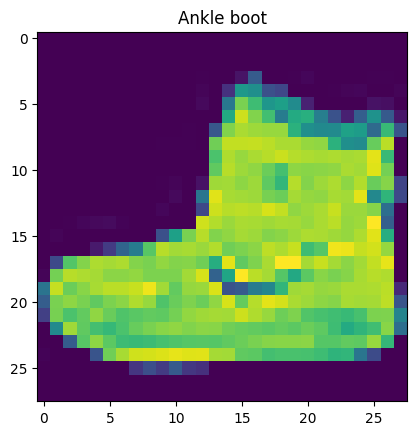

In [11]:
plt.imshow(image.squeeze()) 
plt.title(class_names[label])
plt.show()


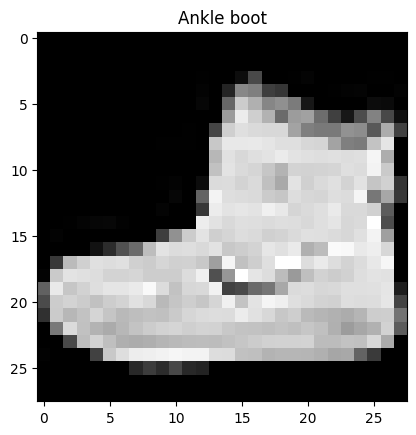

In [12]:
plt.imshow(image.squeeze(), cmap='grey') 
plt.title(class_names[label])
plt.show()


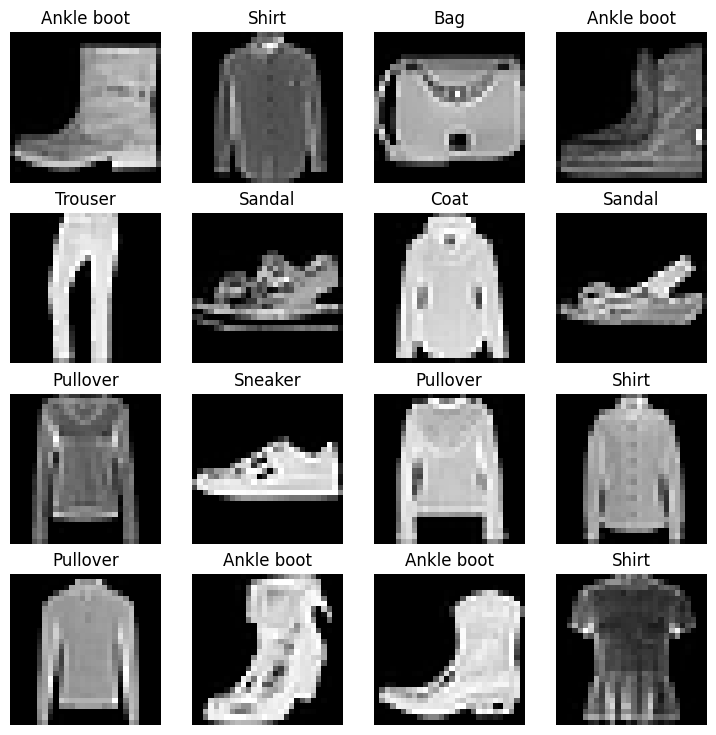

In [13]:
# Plot more images
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4

for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='grey')
    plt.title(class_names[label])
    plt.axis(False)

Do you think these items of clothing (images) could be modeled with pure linear lines? Or do you think we'll need non_linearities?

## 2. Prepare DataLoader

Right now, our data is in the form of PyTorch Datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches (or mini-batches).

Why would we do this?

1. It is more computationally efficient, as in, your computer hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32).
2. It gives our neural network more chances to update its gradients per epoch.

In [14]:
# Setup the batch size hyperparameter
batch_size = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1a1db22d590>,
 <torch.utils.data.dataloader.DataLoader at 0x1a1da2ed110>)

In [15]:
# Let's chech out what we've created

print(f'Dataloaders: {train_dataloader, test_dataloader}')
print(f'Length of train_dataloaer: {len(train_dataloader)} batches of {batch_size}...')
print(f'Length of train_dataloaer: {len(test_dataloader)} batches of {batch_size}...')

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001A1DB22D590>, <torch.utils.data.dataloader.DataLoader object at 0x000001A1DA2ED110>)
Length of train_dataloaer: 1875 batches of 32...
Length of train_dataloaer: 313 batches of 32...


In [16]:
# Check out what's inside the training dataloader

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Img shape: torch.Size([1, 28, 28]), Label: 6, Label shape: torch.Size([])


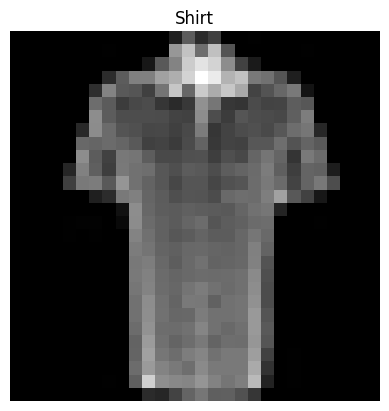

In [17]:
# SHow a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f'Img shape: {img.shape}, Label: {label}, Label shape: {label.shape}')

## 3. Model 0: Build a baseline model

When starting to build a series of machine learning modelling experiments, it's best pracice to start with a baseline model.

A baseline model is a simple model you will try and improve upow with subsequent models/experiments.

In other words: start simply and add complexity when necessary.

In [18]:
# Create a flatten layer

flatten_model = nn.Flatten()

# Get a single sample

x = train_features_batch[0]

# Flatten the sample

output = flatten_model(x)
x.shape, output.shape, output.squeeze().shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]), torch.Size([784]))

In [19]:
class FashioMnistModelV0(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape)#,
            # nn.ReLU()
        ) 
    def forward(self, x):
        return self.layer_stack(x)

In [20]:
torch.manual_seed(42)

# Setup model with input parameters

model_0 = FashioMnistModelV0(
    input_shape=28**2,
    hidden_units=10,
    output_shape=len(class_names) #10
).to("cpu")

model_0

FashioMnistModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [21]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0((dummy_x))

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [22]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss funciton - since we're workign with multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer `torch.optim.SGD()` 
* Evaluation metric - since we're working on a classification problem, let's see accuracy on a evaluation

In [23]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
    print('Exist')
else:
    print('Downlaoding')
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
    with open("helper_functions.py", 'wb') as f:
        f.write(request.content)

Exist


In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

### 3.2 Creating a function to time our experiments

Machine learning is very experimental. 

Two of the main things you'll often want to track are:
1. Model's performance (loss and evaluation values)
2. How fast it runs

In [25]:
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device: torch.device=None):
    """ Prints difference between start and end time

    Args:
        start (float): start time
        end (float): end time
        device (torch.device, optional): _description_. Defaults to None.

    Returns:
        _type_: _description_
    """
    
    total_time = end - start
    print(f'Train time on {device}: {total_time:.3f} seconds')
    return total_time

In [26]:
start_time = timer()
# code...
end_time = timer()

print_train_time(start_time, end_time, device)

Train time on cuda: 0.000 seconds


4.639999997380073e-05

In [27]:
# UPTOHERE: 3.3 Creating a training loop and training a model on batches of data
# Highlight that the optimizer will uptade a model's parameters once per batch rather than per epoch

### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*.
4. Print out what's happening.
5. Time it all (for fun).


In [28]:
# Import tqdm for progress bar
from tqdm.auto import tqdm
from helper_functions import accuracy_fn

c:\Users\Paweł\Documents\KursStreamlit\kursstreamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

accuracy = Accuracy(task='multiclass', num_classes = 10)

# Set the number of epochs (we'll keep this small for faster training time)
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n------')
    
    ### Training
    train_loss = 0
    
    # Add a loop to loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        
        # 1. Forward pass
        y_pred = model_0(X)
        
        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        
        # 3. Optimizer zero grad
        optimizer.zero_grad()
        
        # 4. Loss backward
        loss.backward()
        
        # 5. Optimizer step
        optimizer.step()
        
        if batch % 400 == 0:
            print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')
            
    # Divide total train loss by length of train dataloader
    train_loss /= len(train_dataloader)
    
    ### Testing loop
    test_loss = 0
    correct, total = 0, 0
    model_0.eval()
    accuracy.reset()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X_test)
            
            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y_test)
            
            # 3. Calculate accuracy
            accuracy.update(test_pred, y_test)
            # test_acc += accuracy_fn(y_test, test_pred.argmax(dim=1))
            
        # Calculate the test loss average per batch
        test_loss /= len(test_dataloader)
        
        # Calculate the test acc average per batch
        test_acc = accuracy.compute().item()
        
    # Print out what's happening
    
    print(f'\n Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}')
    
# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                            end=train_time_end_on_cpu, 
                                            device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:13<00:27, 13.79s/it]


 Train loss: 0.5904 | Test loss: 0.5095 | Test acc: 0.8203
Epoch: 1
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:29<00:14, 14.75s/it]


 Train loss: 0.4763 | Test loss: 0.4799 | Test acc: 0.8318
Epoch: 2
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:45<00:00, 15.01s/it]


 Train loss: 0.4550 | Test loss: 0.4766 | Test acc: 0.8341
Train time on cpu: 45.040 seconds


In [30]:
str(next(model_0.parameters()).device)

'cpu'

## 4. Make predictions and get Model 0 results

In [31]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn: torchmetrics.Accuracy,
               device: torch.device = device):
    """ Function which can be used to evaluate a classification model

    Args:
        model (torch.nn.Module): _description_
        data_loader (torch.utils.data.DataLoader): _description_
        loss_fn (torch.nn.Module): _description_
        accuracy_fn (torchmetrics.Accuracy): _description_

    Returns:
        dictionary with informations about a evaluation
    """
    # start = timer()
    loss = 0
    model.eval()
    with torch.inference_mode():
        accuracy_fn.reset()
        for X,y in tqdm(data_loader):
            X, y = X.to(device), y.to(device)
            # Make predictions
            y_pred = model(X)
            
            # Accumulate the loss and acc values per batch
            loss += loss_fn(y_pred, y)
            accuracy_fn.update(y_pred, y)
            
        loss /= len(data_loader)
        
        acc = accuracy_fn.compute().item()
    # end = timer()
    
    # print_train_time(start, end, 'cpu')
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": f'{loss.item():.4f}',
            "model_acc": f'{acc:.4f}'}
    
# Calculate model 0 results on test dataset
model_0_results = eval_model(model = model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy,
                             device='cpu')
model_0_results    
     

100%|██████████| 313/313 [00:01<00:00, 169.59it/s]


{'model_name': 'FashioMnistModelV0',
 'model_loss': '0.4766',
 'model_acc': '0.8341'}

## 5. Setup device agnostic-code (for using a GPU if there is one)

In [32]:
!nvidia-smi

Sat Aug  9 23:27:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.00                 Driver Version: 577.00         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   57C    P0             19W /   80W |     522MiB /   6144MiB |     11%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [33]:
# import torch 
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

In [34]:
# Create a model with linear and non linear layers

class FashioMnistModelV1(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into a single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )
        
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x) 

In [35]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashioMnistModelV1(input_shape=28**2,
                             hidden_units=10,
                             output_shape=len(class_names)).to(device) # send to the GPU if its available

### 6.1 Setup loss, optimizer and evaluation metrics

In [36]:
accuracy = Accuracy(task='multiclass', num_classes=len(class_names)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.1)

### 6.2 Functionizing training and evaluation/testing loops

Lets create a function for:
* training loop - `train_step()`
* testing loop - `test_step()`

In [37]:
def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn: torchmetrics.Accuracy,
    device: torch.device = device
):
    """ Training a model
    Args:
        model (torch.nn.Module): _description_
        data_loader (torch.utils.data.DataLoader): _description_
        loss_fn (torch.nn.Module): _description_
        optimizer (torch.optim.Optimizer): _description_
        accuracy_fn (torchmetrics.Accuracy): _description_
        device (torch.device, optional): _description_. Defaults to device.
    """
    ### Training
    train_loss = 0
    accuracy_fn.reset()
    model.train()
        
    # Add a loop to loop through the training batches
    for batch, (X, y) in enumerate(data_loader):
        # put the data on target device         
        X, y = X.to(device), y.to(device)
            
        # 1. Forward pass
        y_pred = model(X)
            
        # 2. Calculate loss and accuracy (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        accuracy_fn.update(y_pred, y)
            
        # 3. Optimizer zero grad
        optimizer.zero_grad()
            
        # 4. Loss backward
        loss.backward()
            
        # 5. Optimizer step
        optimizer.step()
            
        # if batch % 400 == 0:
        #     print(f'Looked at {batch * len(X)}/{len(data_loader.dataset)} samples')
                
    # Divide total train loss by length of train dataloader
    train_loss /= len(data_loader)
    train_acc = accuracy.compute().item()
        
    print(f'Train loss: {train_loss:.4f} | Train_acc: {train_acc:.2f}%')

In [38]:
def test_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn: torchmetrics.Accuracy,
    device: torch.device = device
):
    test_loss = 0
    
    # put the model in eval mode
    model.eval()
    
    # Turn on inference mode contect manager
    with torch.inference_mode():
        for X,y in data_loader:
            # Send the data to the target device
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate the loss/acc
            test_loss += loss_fn(test_pred, y)
            accuracy_fn.update(test_pred, y)
            
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc = accuracy_fn.compute().item()
    print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.2f}%')

In [39]:
torch.manual_seed(42)

#measure time
start_gpu = timer()

# set epochs 
epochs = 3

# Create a optimization and evaluation loop using train_step() and test_step()

for epoch in tqdm(range(epochs)):
    
    print(f'Epoch: {epoch}\n--------')
    
    train_step(
        model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy,
        device=device
    )
    
    test_step(
        model = model_1,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy
    )
    
end_gpu = timer()

print_train_time(start_gpu, end_gpu, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 1.0920 | Train_acc: 0.61%


 33%|███▎      | 1/3 [00:20<00:41, 20.70s/it]

Test loss: 0.9564 | Test accuracy: 0.62%
Epoch: 1
--------
Train loss: 0.7810 | Train_acc: 0.72%


 67%|██████▋   | 2/3 [00:39<00:19, 19.44s/it]

Test loss: 0.7223 | Test accuracy: 0.72%
Epoch: 2
--------
Train loss: 0.6703 | Train_acc: 0.76%


100%|██████████| 3/3 [00:58<00:00, 19.57s/it]

Test loss: 0.6850 | Test accuracy: 0.76%
Train time on cuda: 58.699 seconds


58.69936550000011

In [40]:
model_0_results

{'model_name': 'FashioMnistModelV0',
 'model_loss': '0.4766',
 'model_acc': '0.8341'}

In [41]:
def train_and_test_step(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn: torchmetrics.Accuracy,
    device: torch.device = device,
    epochs: int = 5
):
    """ Function which collects two previous function to automate everything

    Args:
        model (torch.nn.Module): _description_
        train_dataloader (torch.utils.data.DataLoader): _description_
        test_dataloader (torch.utils.data.DataLoader): _description_
        loss_fn (torch.nn.Module): _description_
        optimizer (torch.optim.Optimizer): _description_
        accuracy_fn (torchmetrics.Accuracy): _description_
        device (torch.device, optional): _description_. Defaults to device.
        epochs (int, optional): _description_. Defaults to 5.
    """
    #measure time
    start_time = timer()

    # Create a optimization and evaluation loop using train_step() and test_step()

    for epoch in tqdm(range(epochs)):
        
        print(f'Epoch: {epoch}\n--------')
        
        train_step(
            model=model,
            data_loader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device
        )
        
        test_step(
            model = model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn
        )
        
    end_time = timer()

    print_train_time(start_time, end_time, device)

In [42]:
train_and_test_step(
    model=model_1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    accuracy_fn=accuracy,
    device=device,
    epochs=1
)

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 0.6438 | Train_acc: 0.77%


100%|██████████| 1/1 [00:20<00:00, 20.54s/it]

Test loss: 0.6508 | Test accuracy: 0.76%
Train time on cuda: 20.541 seconds


>**Note:** Sometimes, depending on your data/hardware you might find that your model trains faster on CPU than GPU
>
> Why is this?
>
> 1. It could be that the overhead for copying data/model to and from the GPU outweights the compute benefits offered by the GPU.
> 2. The hardware you're using has a better CPU in terms compute capability than the GPU
>
>[Making Deep Learning Go Brrrr From First Principles](https://horace.io/brrr_intro.html)

In [43]:
total_train_time_model_0

45.0399209000002

In [44]:
# get model_1 results dictionary
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy,
    device=device
)

model_1_results

100%|██████████| 313/313 [00:02<00:00, 117.96it/s]


{'model_name': 'FashioMnistModelV1',
 'model_loss': '0.6508',
 'model_acc': '0.7613'}

## Model 2: Building a Convolutional Neural Network (CNN)

CNN's are also know ConvNets.

CNN's are known for their capabilitios to find patterns in visual data.

To find out what's happening inside a CNN, see this [website](https://poloclub.github.io/cnn-explainer/).

In [103]:
# Create a convolutional neural network

class FashionMNISTModelV2(nn.Module):

    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        """_summary_

        Args:
            input_shape (int): number of color channels in images
            hidden_units (int): number of neurons per hidden layer
            output_shape (int): number of classes
        """
        super().__init__()
        # Create a conv layer - https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1), # values we can set ourselves in our NN's are called hyperparameters
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html 
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        print(x.shape)
        x = self.conv_block_2(x)
        print(x.shape)
        return self.classifier(x)

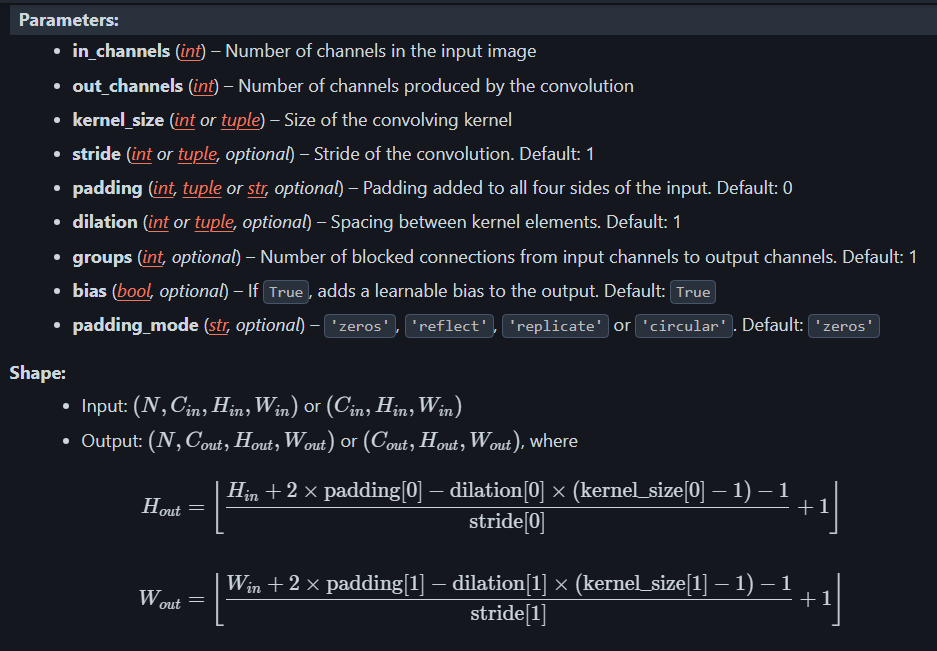

In [104]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, # number of color channels in our images
                              hidden_units=10,
                              output_shape=len(class_names)
                              )

### 7.1 Stepping through `nn.Conv2d()`

Here's the [documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) for `nn.Conv2d()`

In [58]:
torch.manual_seed(42)

# Create a batch of images

images = torch.randn(size=(32,3,64,64))
test_image = images[0]

print(f'Image batch shape: {images.shape}')
print(f'Single image shape: {test_image.shape}')
print(f'Test image:\n {test_image}')

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.8325317..4.2208853].


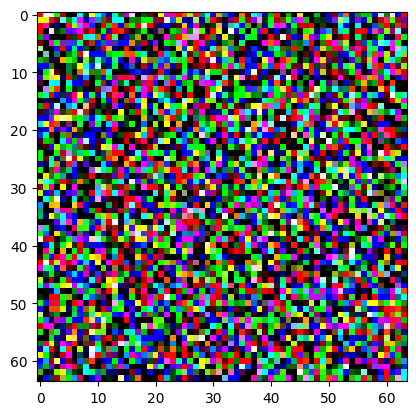

In [56]:
test_image = test_image.permute(1, 2, 0)

plt.imshow(img)


In [63]:
# Create a single conv2wd layer

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3, # same as (3, 3)
    stride=1,
    padding=1
)

# pass the data thorugh the convolutional layer

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

In [64]:
# Create a single conv2wd layer

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3, # same as (3, 3)
    stride=1,
    padding=2
)

# pass the data thorugh the convolutional layer

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 66, 66])

In [65]:
# Create a single conv2wd layer

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3, # same as (3, 3)
    stride=1,
    padding=0
)

# pass the data thorugh the convolutional layer

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

In [80]:
# Create a single conv2wd layer

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3, # same as (3, 3)
    stride=1,
    padding=1
)

# pass the data thorugh the convolutional layer

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 64, 64])

### 7.2 Stepping through [`nn.MaxPool2d()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

In [81]:
test_image.shape

torch.Size([3, 64, 64])

In [83]:
# Create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

In [84]:
# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image)

# Pass data thorugh the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)

In [86]:
# Print out original image shape w/o unsqueezed dimension

print(f'Test iamge original shape: {test_image.shape}')
# print(f'Test iamge unsqueezed shape: {test_image.unsqueeze(0).shape}')
print(f'Shape after going through conv_layer(): {test_image_through_conv.shape}')
print(f'Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}')

Test iamge original shape: torch.Size([3, 64, 64])
Shape after going through conv_layer(): torch.Size([10, 64, 64])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([10, 32, 32])


In [92]:
torch.manual_seed(42)

# Create a random tensor with a similar number of dimensions to our images 

random_tensor = torch.randn(size=(1,1,2,2))
random_tensor, random_tensor.shape

(tensor([[[[0.3367, 0.1288],
           [0.2345, 0.2303]]]]),
 torch.Size([1, 1, 2, 2]))

In [89]:
max_pool_layer = nn.MaxPool2d(kernel_size=2)

In [91]:
max_pool_layer(random_tensor), max_pool_layer(random_tensor).shape

(tensor([[[[0.3367]]]]), torch.Size([1, 1, 1, 1]))

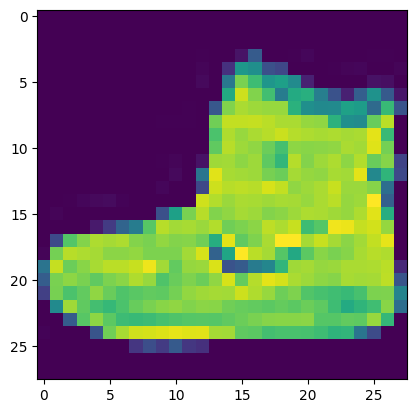

In [96]:
plt.imshow(image.squeeze())

In [99]:
# pass image through model
model_2(image)

torch.Size([10, 14, 14])
torch.Size([10, 7, 7])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x49 and 0x10)

In [100]:
rand_image_tensor = torch.randn(size=(1,28,28))

In [101]:
model_2(rand_image_tensor)

torch.Size([10, 14, 14])
torch.Size([10, 7, 7])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x49 and 0x10)